In [ ]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Subset Olink RVAT significant

# olink_burden_test_file = "proteomics_prs_am_loftee_mac20_burden_regression_results.parquet"
# olink_burden_test_file = "proteomics_prs_loftee_mac20_burden_regression_results.parquet"
olink_burden_test_file = "proteomics_prs_df_loftee_mac20_burden_regression_results.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/{olink_burden_test_file} -o /home/dnanexus/data_dir/

olink_whitelist = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{olink_burden_test_file}')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_correlations_file = "olink_all_mac20_lofteeHC_correlations.parquet"
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/{olink_correlations_file} -o /home/dnanexus/data_dir/

olink_corrs = (
    pl.read_parquet(f'/home/dnanexus/data_dir/{olink_correlations_file}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir/proteomics_prs_df_loftee_mac20_burden_reg
ression_results.parquet" already exists but -f/--overwrite was not set
Error: path
"/home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet"
already exists but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000163606""","""ENSG00000163606_olink""",0.204082,0.204082,1.0
"""ENSG00000144857""","""ENSG00000144857_olink""",0.162616,0.162616,1.0
"""ENSG00000161270""","""ENSG00000161270_olink""",0.175562,0.175562,1.0
"""ENSG00000091129""","""ENSG00000091129_olink""",0.165924,0.165924,1.0
"""ENSG00000132437""","""ENSG00000132437_olink""",0.214824,0.214824,1.0
…,…,…,…,…
"""ENSG00000101160""","""ENSG00000101160_olink""",0.386419,0.386419,1.0
"""ENSG00000130528""","""ENSG00000130528_olink""",0.305544,0.305544,1.0
"""ENSG00000110448""","""ENSG00000110448_olink""",0.337765,0.337765,1.0


In [3]:
# Configuration and paths
mac = 20
abs_phenotypes = False
extreme_pheno_dir = 'bottom'
# abs_phenotypes = True

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_odds.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
…,…,…,…,…
"""regulatory""","""fz_blood_mean""","""crimson""","""Flashzoi mean across RNA blood""",1
"""regulatory""","""fz_all_mean""","""#FFA500""","""Flashzoi mean across RNA all""",1
"""regulatory_nondir""","""promoterai_abs""","""#80CBC4""","""PromoterAI abs""",-1


In [4]:
# new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
# new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv40_ukbbgym.parquet"
# !dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

# new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

# new_anno_df = (
#     pl.read_parquet(new_anno_local)
#     .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
#     .with_columns(
#         fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
#         fz_blood_mean = pl.mean_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533']).abs()),
#     )
#     .select(['id', 'region', 'fz_blood_mean', 'fz_all_mean'])
#     .lazy()
# )

# new_anno_df.head().collect()

In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")


# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .with_columns(
        encode_any_tf = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_tf', 'encode_ca-tf']),
        encode_enhancer = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pels', 'encode_dels']),
        encode_promoter = pl.any_horizontal((pl.col(c) == 1) for c in ['encode_pls', 'encode_ca-h3k4me3']),
    )
    .filter(
        # Olink whitelist
        (pl.col('region').is_in(olink_whitelist['region'].unique())),
        
        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # UPDATE WITH NEW VEP MANE ANNOS
        ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),

        # Core promoter
        # (pl.col('promoterai_is_na') == False),

        # VEP consequences
        # (pl.col('consequence_missense_variant') == True),

        # Choose protein domain
        # (pl.col('ted_domain') == True),
        # (pl.col('mobi_curated_disorder_priority') == True),
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('low_complexity_domain') == True),

        # Choose regulatory region
        # (pl.col('encode_any_tf') == True),
        # (pl.col('encode_enhancer') == True),
        (pl.col('encode_promoter') == True),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
    )
)

# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'regulatory_nondir'] # CDS
# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # missense
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
selected_categories = ['genetic_diversity', 'splicing', 'conservation', 'regulatory', 'regulatory_nondir', '3utr'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
selected_annos = list(set(selected_annos).intersection(set(existing_annos)))
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_75140/2029758911.py:81: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_75140/2029758911.py:90: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


abexp_max,abexp_abs_max,promoterai_abs,id,region,aparent2,cadd_raw,gpn_score,verphylop,delta_score,promoterai,pangolin_score,absplice_dna_max,abexp_min,absplice2_max
f32,f32,f32,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
-0.015266,0.016585,0.0,"""chr9:100021984:G:A""","""ENSG00000023318""",0.0,0.616919,-2.27,0.621,0.0,0.0,0.0,0.003,-0.016585,0.000341
0.002667,0.002667,0.0,"""chr5:177399102:A:C""","""ENSG00000131187""",0.0,0.607802,-1.64,-0.052,0.0,0.0,0.0,0.0,0.0,0.0
0.002667,0.002667,0.0,"""chr5:177399102:A:C""","""ENSG00000131187""",0.0,0.607802,-1.64,-0.052,0.0,0.0,0.0,0.0,0.0,0.0
0.002667,0.022285,0.0,"""chr9:133642502:C:T""","""ENSG00000123454""",0.0,0.403744,-1.71,0.127,0.0,0.0,0.0,0.003,-0.022285,0.000123
0.002469,0.019552,0.0,"""chr9:133643109:C:T""","""ENSG00000123454""",0.0,0.573539,-1.47,-0.567,0.1,0.0,0.02,0.0,-0.019552,0.000034
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.00104,0.00104,0.0017,"""chr9:128340477:G:A""","""ENSG00000167114""",0.0,0.737276,-2.44,0.156,0.0,-0.0017,0.0,0.0,0.000079,0.0
0.0,0.006189,0.0,"""chr1:174711713:C:T""","""ENSG00000152061""",0.0,0.500459,0.35,0.0,0.0,0.0,0.0,0.0,-0.006189,0.0
0.0,0.006261,0.0,"""chr12:40955011:G:A""","""ENSG00000018236""",0.0,0.220451,1.6,0.019,0.0,0.0,0.0,0.001,-0.006261,0.000033


In [6]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_75140/3727860496.py:28: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr9:100021984:G:A""","""ENSG00000023318""","""score_pai3d""",1
"""chr5:177399102:A:C""","""ENSG00000131187""","""score_pai3d""",1
"""chr5:177399102:A:C""","""ENSG00000131187""","""score_pai3d""",1
"""chr9:133642502:C:T""","""ENSG00000123454""","""score_pai3d""",1
"""chr9:133643109:C:T""","""ENSG00000123454""","""score_pai3d""",1


In [7]:
melted_anno = (
    anno.lazy()

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Keep variants that don't have fillna annotation
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_75140/315562140.py:45: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr19:40265605:C:G""","""ENSG00000105221""","""absplice_dna_max""",0.001,"""splicing""",1,162490.0
"""chr12:68933114:G:A""","""ENSG00000135678""","""absplice_dna_max""",0.003,"""splicing""",1,62236.0
"""chr1:161084418:C:T""","""ENSG00000143217""","""absplice_dna_max""",0.003,"""splicing""",1,62236.0
"""chr11:715458:T:A""","""ENSG00000177106""","""absplice_dna_max""",0.001,"""splicing""",1,162490.0
"""chr3:28279196:C:G""","""ENSG00000187118""","""absplice_dna_max""",0.001,"""splicing""",1,162490.0
…,…,…,…,…,…,…
"""chr16:1688471:T:C""","""ENSG00000206053""","""absplice_dna_max""",0.001,"""splicing""",1,162490.0
"""chr7:8181683:T:C""","""ENSG00000003147""","""absplice_dna_max""",0.001,"""splicing""",1,162490.0
"""chr18:63970333:G:A""","""ENSG00000166401""","""absplice_dna_max""",0.003,"""splicing""",1,62236.0


In [8]:
melted_anno['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""cadd_raw""",365850
"""abexp_max""",365850
"""promoterai_abs""",365850
"""abexp_min""",365850
"""gpn_score""",365839
…,…
"""pangolin_score""",204438
"""promoterai""",178554
"""absplice_dna_max""",172733


In [ ]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)

In [10]:
olink_appv.head().collect()

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,mean_pheno_value_rank,mean_pheno_value_ptile
str,str,i32,f32,f32,f32,f32
"""chr12:24805471:G:A""","""ENSG00000060982_olink""",1,0.328067,null,1.720632e6,0.36397
"""chr12:122768837:C:G""","""ENSG00000139726_olink""",1,-1.312343,null,4.311464e6,0.933468
"""chr2:102332039:T:C""","""ENSG00000115604_olink""",1,0.249114,null,2.082593e6,0.392066
"""chr2:37346399:G:A""","""ENSG00000115828_olink""",1,1.00197,null,705046.0,0.133705
"""chr16:89195863:C:G""","""ENSG00000129910_olink""",1,-0.059154,null,2.813642e6,0.530968


## Odds ratio computation

In [ ]:
n_steps = 101
min_rank_cutoff = 1_0
max_rank_cutoff = 1_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.99

# Convert phenotype percentile threshold to z-score (assuming standard Gaussian)
zscore_threshold = stats.norm.ppf(or_threshold_pheno)
print(f"Phenotype threshold: {or_threshold_pheno} → z-score: {zscore_threshold:.4f}")

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

# Prepare cutoffs once
cutoffs_sorted = (
    pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})
    .with_columns(pl.col('rank_cutoff').cast(pl.Float32))
    .sort('rank_cutoff')
    .collect()
)

cutoffs_sorted

In [ ]:
# --- Pre-aggregate per-(region, annotation, rank_cutoff) counts, then bootstrap ---
# We assume mean_pheno_value ~ N(0,1). Extreme = z-score > zscore_threshold.
# Bootstrap across gene-trait pairs to get CIs that account for non-independence.

id_region = anno.select(['id', 'region']).unique().lazy()

# Stream-collect base data ONCE: compute is_extreme using z-score threshold
gp_base = (
    olink_appv
    .join(id_region, on='id', how='inner')
    .join(olink_whitelist.lazy(), on=['region', 'phenotype'], how='inner')
    .with_columns(
        is_extreme = (
            pl.when(pl.col('loftee_corr_dir') == -1)
                .then(-pl.col('mean_pheno_value'))
                .otherwise(pl.col('mean_pheno_value'))
            >= zscore_threshold
        )
    )
    .select(['id', 'region', 'is_extreme'])
    .collect(engine='streaming')
)

print(f"gp_base: {gp_base.shape}, extreme: {gp_base['is_extreme'].sum()}")

# --- Step 1: Pre-aggregate per (region, annotation, rank_cutoff) 2x2 table counts ---
all_regions = sorted(olink_whitelist['region'].unique().to_list())
n_regions = len(all_regions)
all_regions_df = pl.DataFrame({'region': all_regions})

annotations_list = sorted(melted_anno['annotation'].unique().to_list())
n_annotations = len(annotations_list)
n_cutoffs = cutoffs_sorted.shape[0]

# 4D array: (n_annotations, n_regions, n_cutoffs, 4)
# 4 = [n_dis_above, n_notdis_above, n_dis_below, n_notdis_below]
counts_4d = np.zeros((n_annotations, n_regions, n_cutoffs, 4), dtype=np.int64)

for a_idx, annotation in enumerate(tqdm(annotations_list, desc='Pre-aggregating')):
    anno_ranks = (
        melted_anno
        .filter(pl.col('annotation') == annotation)
        .select(['id', 'region', 'annotation_score_dircor_rank_desc'])
    )

    # Group by (region, rank), count extreme vs total
    region_rank_counts = (
        gp_base.lazy()
        .join(anno_ranks.lazy(), on=['id', 'region'], how='inner')
        .group_by(['region', 'annotation_score_dircor_rank_desc'])
        .agg(
            n_extreme = pl.col('is_extreme').sum().cast(pl.Int64),
            n_total = pl.len().cast(pl.Int64),
        )
        .collect()
        .sort(['region', 'annotation_score_dircor_rank_desc'])
        .with_columns(
            cum_extreme = pl.col('n_extreme').cum_sum().over('region'),
            cum_total = pl.col('n_total').cum_sum().over('region'),
        )
    )

    # Per-region totals
    region_totals = (
        region_rank_counts
        .group_by('region')
        .agg(
            total_extreme = pl.col('n_extreme').sum(),
            total_count = pl.col('n_total').sum(),
        )
    )

    # Cross join cutoffs × ALL regions, then asof join by region
    per_region = (
        cutoffs_sorted
        .join(all_regions_df, how='cross')
        .sort(['region', 'rank_cutoff'])
        .join_asof(
            region_rank_counts.sort(['region', 'annotation_score_dircor_rank_desc']),
            left_on='rank_cutoff',
            right_on='annotation_score_dircor_rank_desc',
            by='region',
            strategy='backward',
        )
        .with_columns(
            cum_extreme = pl.col('cum_extreme').fill_null(0),
            cum_total = pl.col('cum_total').fill_null(0),
        )
        .join(region_totals, on='region', how='left')
        .with_columns(
            total_extreme = pl.col('total_extreme').fill_null(0),
            total_count = pl.col('total_count').fill_null(0),
        )
        .with_columns(
            n_dis_above = pl.col('cum_extreme'),
            n_notdis_above = pl.col('cum_total') - pl.col('cum_extreme'),
            n_dis_below = pl.col('total_extreme') - pl.col('cum_extreme'),
            n_notdis_below = (pl.col('total_count') - pl.col('total_extreme'))
                           - (pl.col('cum_total') - pl.col('cum_extreme')),
        )
        .sort(['region', 'rank_cutoff'])
    )

    # Vectorized fill: sorted by (region, rank_cutoff), reshape to (n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 0] = per_region['n_dis_above'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 1] = per_region['n_notdis_above'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 2] = per_region['n_dis_below'].to_numpy().reshape(n_regions, n_cutoffs)
    counts_4d[a_idx, :, :, 3] = per_region['n_notdis_below'].to_numpy().reshape(n_regions, n_cutoffs)

print(f"Pre-aggregated: {counts_4d.shape} = {n_annotations} annos × {n_regions} regions × {n_cutoffs} cutoffs × 4 counts")
print(f"Memory: {counts_4d.nbytes / 1e6:.1f} MB")

# --- Step 2: Point estimate (sum across all regions) ---
total_counts = counts_4d.sum(axis=1)  # (n_annotations, n_cutoffs, 4)
with np.errstate(divide='ignore', invalid='ignore'):
    point_or = (total_counts[:, :, 0] / total_counts[:, :, 1]) / \
               (total_counts[:, :, 2] / total_counts[:, :, 3])

# --- Step 3: Bootstrap CIs across gene-trait pairs ---
n_boot = 1000
rng = np.random.default_rng(42)
boot_ors = np.full((n_boot, n_annotations, n_cutoffs), np.nan)

for b in tqdm(range(n_boot), desc='Bootstrapping'):
    idx = rng.choice(n_regions, size=n_regions, replace=True)
    sampled = counts_4d[:, idx, :, :].sum(axis=1)  # (n_annotations, n_cutoffs, 4)
    with np.errstate(divide='ignore', invalid='ignore'):
        boot_ors[b] = (sampled[:, :, 0] / sampled[:, :, 1]) / (sampled[:, :, 2] / sampled[:, :, 3])

# 95% CIs (percentile method — no log transform needed since percentiles are monotone-invariant)
boot_ci_lower = np.nanpercentile(boot_ors, 2.5, axis=0)
boot_ci_upper = np.nanpercentile(boot_ors, 97.5, axis=0)

# --- Build output DataFrame ---
cutoff_values = cutoffs_sorted['rank_cutoff'].to_numpy()
anno_idx, cutoff_idx = np.meshgrid(np.arange(n_annotations), np.arange(n_cutoffs), indexing='ij')

or_df = (
    pl.DataFrame({
        'annotation': np.array(annotations_list)[anno_idx.ravel()],
        'rank_cutoff': cutoff_values[cutoff_idx.ravel()],
        'n_dis_above': total_counts[:, :, 0].ravel(),
        'n_notdis_above': total_counts[:, :, 1].ravel(),
        'n_dis_below': total_counts[:, :, 2].ravel(),
        'n_notdis_below': total_counts[:, :, 3].ravel(),
        'odds_ratio': point_or.ravel(),
        'ci_lower': boot_ci_lower.ravel(),
        'ci_upper': boot_ci_upper.ravel(),
    })
    .filter(pl.col('odds_ratio').is_finite() & (pl.col('odds_ratio') > 0))
    .sort('rank_cutoff', descending=True)
)

or_df

## Plotting

In [13]:
print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        log_rank_cutoff = pl.col('rank_cutoff').log10(),
        log_rank_cutoff_inv = (1 / pl.col('rank_cutoff')).log10(),
    )
    .join(
        anno_config_df.filter(pl.col('category').is_in(selected_categories)).select(['annotation', 'color', 'label', 'category']).unique(),
        on='annotation',
        how='left'
    )
    .filter(pl.col('category').is_in(selected_categories))
    .sort('log_rank_cutoff')
    
    # Remove shaky data points
    .filter(
        (pl.col('n_dis_above')>5),
        (pl.col('n_dis_below')>5),
        (pl.col('n_notdis_above')>5),
        (pl.col('n_notdis_below')>5),
    )
)

plt_df

unique percentile cutoffs: 100


annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,se_log_or,ci_lower,ci_upper,log_rank_cutoff,log_rank_cutoff_inv,color,label,category
str,f32,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,str,str
"""promoterai""",60.0,6,6,726,38238,52.669421,0.578565,16.946284,163.69771,1.778151,-1.778151,"""#00A99D""","""PromoterAI""","""regulatory"""
"""promoterai""",66.0,6,7,726,38237,45.144038,0.557609,15.134022,134.662428,1.819544,-1.819544,"""#00A99D""","""PromoterAI""","""regulatory"""
"""promoterai""",74.0,6,7,726,38237,45.144038,0.557609,15.134022,134.662428,1.869232,-1.869232,"""#00A99D""","""PromoterAI""","""regulatory"""
"""promoterai""",82.0,6,7,726,38237,45.144038,0.557609,15.134022,134.662428,1.913814,-1.913814,"""#00A99D""","""PromoterAI""","""regulatory"""
"""promoterai""",91.0,6,8,726,38236,39.5,0.54136,13.67044,114.133123,1.959041,-1.959041,"""#00A99D""","""PromoterAI""","""regulatory"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""abexp_min""",346153.0,1099,73970,62,5668,1.358252,0.131259,1.050148,1.75675,5.539268,-5.539268,"""#b5de2b""","""AbExp min""","""regulatory"""
"""cadd_raw""",346153.0,1120,75189,41,4449,1.616376,0.159753,1.181836,2.210687,5.539268,-5.539268,"""#1f77b4""","""CADD Raw""","""genetic_diversity"""
"""gpn_score""",346153.0,1095,74804,66,4832,1.071698,0.127613,0.834538,1.376254,5.539268,-5.539268,"""pink""","""GPN-MSA""","""conservation"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


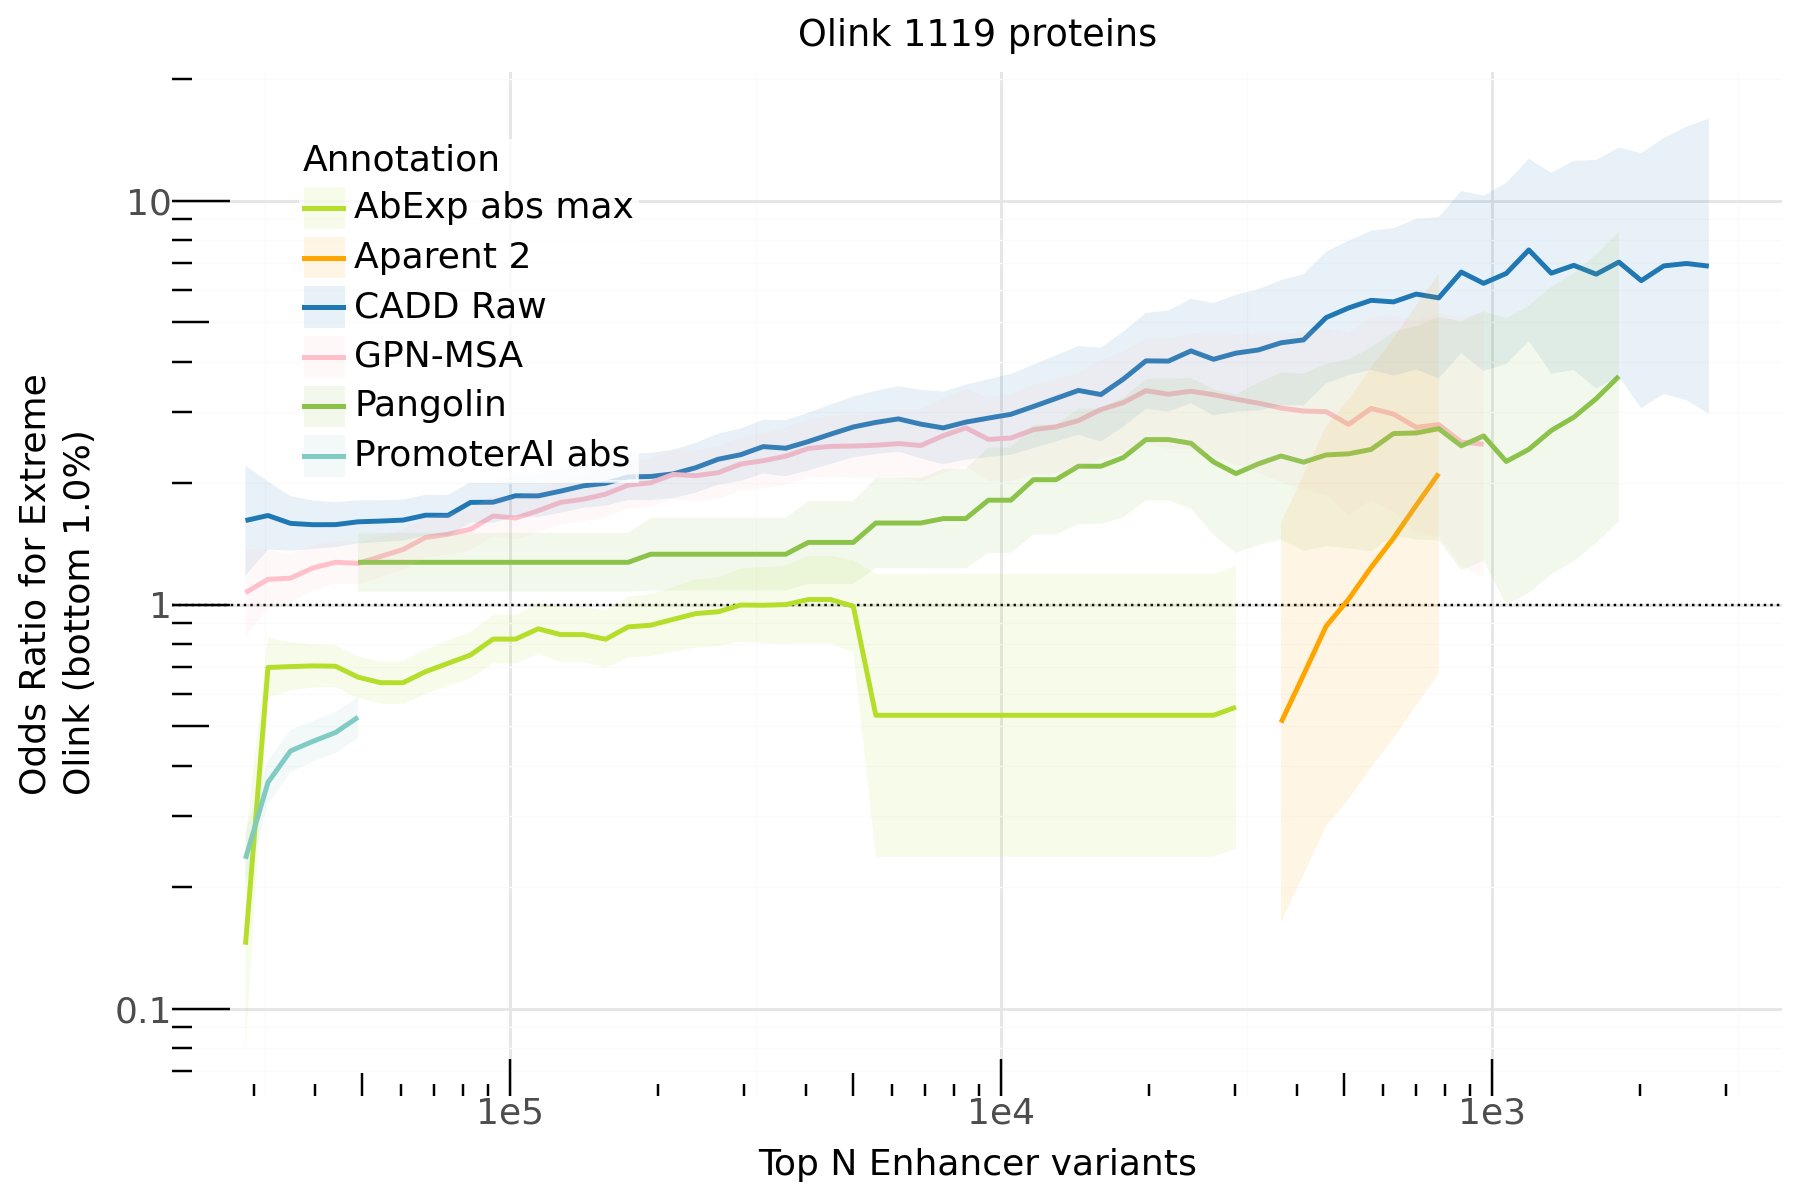

In [16]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') >= -5.5),
        # (pl.col('log_rank_cutoff_inv') <= -3),

        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'absplice2_max', 'abexp_abs_max', 'cadd_raw']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'esmscoremissense', 'score_pai3d', 'gpn_score', 'absplice2_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'pangolin_score', 'delta_score', 'absplice2_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs', 'fz_RNA_blood_abs_max', 'fz_RNA_all_abs_max']))
        (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'pangolin_score', 'promoterai_abs', 'abexp_abs_max', 'aparent2']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'abexp_max', 'promoterai']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)


(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='ci_lower', ymax='ci_upper', fill='label'), alpha=0.1)
    # + loftee_point
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Olink {olink_whitelist.shape[0]} proteins",
        y=f"Odds Ratio for Extreme\nOlink ({extreme_pheno_dir} {pheno_label}%)",
        x=f"Top N Enhancer variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(9, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.1, 0.9), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [15]:
plt_df.head()

annotation,rank_cutoff,n_dis_above,n_notdis_above,n_dis_below,n_notdis_below,odds_ratio,se_log_or,ci_lower,ci_upper,log_rank_cutoff,log_rank_cutoff_inv,color,label,category
str,f32,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,str,str
"""promoterai""",60.0,6,6,726,38238,52.669421,0.578565,16.946284,163.69771,1.778151,-1.778151,"""#00A99D""","""PromoterAI""","""regulatory"""
"""promoterai""",66.0,6,7,726,38237,45.144038,0.557609,15.134022,134.662428,1.819544,-1.819544,"""#00A99D""","""PromoterAI""","""regulatory"""
"""promoterai""",74.0,6,7,726,38237,45.144038,0.557609,15.134022,134.662428,1.869232,-1.869232,"""#00A99D""","""PromoterAI""","""regulatory"""
"""promoterai""",82.0,6,7,726,38237,45.144038,0.557609,15.134022,134.662428,1.913814,-1.913814,"""#00A99D""","""PromoterAI""","""regulatory"""
"""promoterai""",91.0,6,8,726,38236,39.5,0.54136,13.67044,114.133123,1.959041,-1.959041,"""#00A99D""","""PromoterAI""","""regulatory"""
